# 3D Fourier Neural Operator + Heat Equation + Laplace Approximation

This notebook builds a **3D scientific machine learning** example around the periodic heat equation and then adds **Laplace uncertainty quantification** on the final layer of a trained operator network.

What this notebook does:

- generates synthetic 3D heat-diffusion data from random initial temperature fields,
- trains a **3D Fourier Neural Operator (FNO)** to map an initial field $u_0(x,y,z)$ to the field at a later time $u(x,y,z,T)$,
- uses a **physics-aligned residual baseline** so the CPU-executable tutorial remains accurate,
- applies **last-layer Laplace approximation** with a structured Hessian approximation,
- visualizes predictive mean and uncertainty on central 3D slices.

Primary references:

- Z. Li et al., *Fourier Neural Operator for Parametric Partial Differential Equations*.
- G. E. Karniadakis group / Lu et al., *Learning nonlinear operators via DeepONet based on the universal approximation theorem of operators*.
- D. J. C. MacKay, *A Practical Bayesian Framework for Backpropagation Networks*.
- H. Ritter et al., *A Scalable Laplace Approximation for Neural Networks*.
- F. Daxberger et al., *Laplace Redux -- Effortless Bayesian Deep Learning*.


## Physical meaning

We solve the **3D periodic heat equation**

$$
\partial_t u = \kappa \Delta u, \qquad (x,y,z) \in [0,1)^3,
$$

with periodic boundary conditions. In physical terms:

- $u(x,y,z,t)$ is a **temperature field**,
- $u_0(x,y,z)$ is the **initial temperature distribution**,
- $\kappa$ is the thermal diffusivity,
- the PDE says temperature gradients smooth out over time.

The neural operator learns the field-to-field map

$$
\mathcal{G}: u_0(x,y,z) \mapsto u(x,y,z,T).
$$

So the input to the model is **one 3D field** and the output is **one 3D field**.


## Why this notebook uses a residual physics baseline

A 3D notebook has to balance two competing goals:

1. stay faithful to operator learning and uncertainty quantification,
2. remain executable on CPU in a local tutorial setting.

To make that tradeoff explicit, the executable `quick` mode uses a **coarse spectral baseline**:

- a low-pass version of the initial field is evolved analytically through the heat equation,
- the FNO learns only the **high-frequency correction** on top of that baseline.

This is a logical scientific-ML strategy:

- the baseline captures the easy large-scale physics,
- the network focuses on the harder unresolved structure,
- the uncertainty map becomes more informative, especially on out-of-distribution (OOD) high-frequency inputs.

The `full` mode keeps the richer, more standard nonlinear FNO configuration intended for GPU runs at $32^3$ resolution.


In [1]:
# Notebook bootstrap
# Make sure imports resolve to the local `src/` tree instead of an installed package.
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "sciml":
    REPO_ROOT = ROOT.parent.parent
else:
    REPO_ROOT = ROOT
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))


In [2]:
# Core imports and reproducibility
import math
import random
from dataclasses import dataclass, asdict

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from deepuq.methods import LaplaceWrapper
from deepuq.models import FNO3D

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")
print("Device:", device)


Device: cpu


## Configuration

This notebook exposes two modes:

- `quick`: the executed CPU tutorial path used below,
- `full`: a documented GPU-oriented configuration for larger $32^3$ experiments.

The key difference is that `quick` mode intentionally uses a **small linear FNO core** because the heat operator is linear and the goal here is to demonstrate a full 3D SciML + UQ workflow locally.


In [3]:
# Experiment configuration
@dataclass
class ExperimentConfig:
    mode: str = "quick"
    resolution: int = 16
    train_size: int = 256
    val_size: int = 64
    test_size: int = 64
    ood_size: int = 64
    kappa: float = 0.02
    final_time: float = 0.05
    train_max_freq: int = 3
    ood_max_freq: int = 6
    hotspot_amplitude: float = 0.15
    baseline_cutoff: int = 2
    width: int = 4
    modes: tuple[int, int, int] = (4, 4, 4)
    n_blocks: int = 1
    head_hidden_dim: int = 8
    use_coordinate_features: bool = False
    use_nonlinearity: bool = False
    batch_size: int = 64
    epochs: int = 140
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5
    grad_clip: float = 1.0
    laplace_hessian: str = "block_diag"
    laplace_prior_precision: float = 500.0
    laplace_samples: int = 12
    run_lowrank_comparison: bool = False


FULL_CONFIG = ExperimentConfig(
    mode="full",
    resolution=32,
    train_size=512,
    val_size=128,
    test_size=128,
    ood_size=128,
    width=32,
    modes=(10, 10, 10),
    n_blocks=4,
    head_hidden_dim=64,
    use_coordinate_features=True,
    use_nonlinearity=True,
    batch_size=8,
    epochs=200,
    learning_rate=2e-3,
    weight_decay=1e-4,
)

config = ExperimentConfig()
print(asdict(config))


{'mode': 'quick', 'resolution': 16, 'train_size': 256, 'val_size': 64, 'test_size': 64, 'ood_size': 64, 'kappa': 0.02, 'final_time': 0.05, 'train_max_freq': 3, 'ood_max_freq': 6, 'hotspot_amplitude': 0.15, 'baseline_cutoff': 2, 'width': 4, 'modes': (4, 4, 4), 'n_blocks': 1, 'head_hidden_dim': 8, 'use_coordinate_features': False, 'use_nonlinearity': False, 'batch_size': 64, 'epochs': 140, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'grad_clip': 1.0, 'laplace_hessian': 'block_diag', 'laplace_prior_precision': 500.0, 'laplace_samples': 12, 'run_lowrank_comparison': False}


### How to read the configuration

Important knobs:

- `train_max_freq`: maximum Fourier frequency present in the in-domain training data,
- `ood_max_freq`: larger frequency range used to stress the model outside training support,
- `baseline_cutoff`: low-pass cutoff for the physics baseline,
- `width`, `modes`, `n_blocks`: FNO architecture controls,
- `laplace_prior_precision`: controls how tightly the Laplace posterior stays around the MAP solution.

For the executed run below, the chosen setting is intentionally conservative: it makes the tutorial CPU-friendly while still producing a meaningful 3D uncertainty map.


## Dataset generation

The dataset is fully synthetic, but physically meaningful.

1. We sample an initial temperature field $u_0(x,y,z)$ from a random Fourier basis.
2. We evolve it analytically to time $T$ using the exact spectral solution of the heat equation.
3. We split the data into:
   - train / validation / test: low-frequency smooth fields,
   - OOD: higher-frequency fields plus localized hot spots.

The OOD split matters because uncertainty should increase when the test input contains structures that the training operator rarely saw.


In [4]:
# PDE and dataset helpers
# These helpers keep the scientific part explicit instead of hiding the PDE under a black-box loader.
import torch.nn.functional as F


def make_unit_grid(resolution: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    coords = torch.arange(resolution, dtype=torch.float32) / resolution
    return torch.meshgrid(coords, coords, coords, indexing="ij")


def sample_initial_fields(
    n_samples: int,
    resolution: int,
    max_freq: int,
    seed: int,
    hotspot_amplitude: float = 0.0,
) -> torch.Tensor:
    generator = torch.Generator().manual_seed(seed)
    xx, yy, zz = make_unit_grid(resolution)
    fields = []
    for _ in range(n_samples):
        field = torch.zeros_like(xx)
        for fx in range(1, max_freq + 1):
            for fy in range(1, max_freq + 1):
                for fz in range(1, max_freq + 1):
                    amp = 0.3 * torch.randn((), generator=generator) / (fx * fy * fz) ** 2.0
                    phase = 2.0 * math.pi * torch.rand((), generator=generator)
                    field = field + amp * torch.sin(
                        2.0 * math.pi * (fx * xx + fy * yy + fz * zz) + phase
                    )
        if hotspot_amplitude > 0.0:
            cx, cy, cz = [torch.rand((), generator=generator) for _ in range(3)]
            sigma = 0.05
            hotspot = torch.exp(
                -((xx - cx) ** 2 + (yy - cy) ** 2 + (zz - cz) ** 2) / (2.0 * sigma**2)
            )
            field = field + hotspot_amplitude * hotspot
        fields.append(field)
    return torch.stack(fields)


def heat_evolve(fields: torch.Tensor, kappa: float, final_time: float) -> torch.Tensor:
    resolution = fields.size(-1)
    freqs = torch.fft.fftfreq(resolution, d=1.0 / resolution, device=fields.device)
    kx, ky, kz = torch.meshgrid(freqs, freqs, freqs, indexing="ij")
    decay = torch.exp(
        -4.0 * math.pi * math.pi * kappa * final_time * (kx**2 + ky**2 + kz**2)
    )
    field_ft = torch.fft.fftn(fields, dim=(-3, -2, -1), norm="ortho")
    return torch.fft.ifftn(field_ft * decay, dim=(-3, -2, -1), norm="ortho").real


def lowpass_filter(fields: torch.Tensor, cutoff: int) -> torch.Tensor:
    resolution = fields.size(-1)
    freqs = torch.fft.fftfreq(resolution, d=1.0 / resolution, device=fields.device)
    kx, ky, kz = torch.meshgrid(freqs, freqs, freqs, indexing="ij")
    mask = ((kx.abs() <= cutoff) & (ky.abs() <= cutoff) & (kz.abs() <= cutoff)).to(fields.dtype)
    field_ft = torch.fft.fftn(fields, dim=(-3, -2, -1), norm="ortho")
    return torch.fft.ifftn(field_ft * mask, dim=(-3, -2, -1), norm="ortho").real


def coarse_physics_baseline(
    initial_fields: torch.Tensor,
    cutoff: int,
    kappa: float,
    final_time: float,
) -> torch.Tensor:
    return heat_evolve(lowpass_filter(initial_fields, cutoff=cutoff), kappa=kappa, final_time=final_time)


def rmse(pred: torch.Tensor, target: torch.Tensor) -> float:
    return torch.mean((pred - target) ** 2).sqrt().item()


def relative_l2(pred: torch.Tensor, target: torch.Tensor) -> float:
    num = torch.linalg.norm((pred - target).reshape(pred.size(0), -1), dim=1)
    den = torch.linalg.norm(target.reshape(target.size(0), -1), dim=1).clamp_min(1e-8)
    return float((num / den).mean())


In [5]:
# Build train / validation / test / OOD datasets.
# - The in-domain splits contain low-frequency smooth fields.
# - The OOD split adds higher frequencies and localized hot spots.
train_u0 = sample_initial_fields(
    config.train_size,
    config.resolution,
    config.train_max_freq,
    seed=11,
)
val_u0 = sample_initial_fields(
    config.val_size,
    config.resolution,
    config.train_max_freq,
    seed=12,
)
test_u0 = sample_initial_fields(
    config.test_size,
    config.resolution,
    config.train_max_freq,
    seed=13,
)
ood_u0 = sample_initial_fields(
    config.ood_size,
    config.resolution,
    config.ood_max_freq,
    seed=14,
    hotspot_amplitude=config.hotspot_amplitude,
)

train_target = heat_evolve(train_u0, config.kappa, config.final_time)
val_target = heat_evolve(val_u0, config.kappa, config.final_time)
test_target = heat_evolve(test_u0, config.kappa, config.final_time)
ood_target = heat_evolve(ood_u0, config.kappa, config.final_time)

train_baseline = coarse_physics_baseline(train_u0, config.baseline_cutoff, config.kappa, config.final_time)
val_baseline = coarse_physics_baseline(val_u0, config.baseline_cutoff, config.kappa, config.final_time)
test_baseline = coarse_physics_baseline(test_u0, config.baseline_cutoff, config.kappa, config.final_time)
ood_baseline = coarse_physics_baseline(ood_u0, config.baseline_cutoff, config.kappa, config.final_time)

train_inputs = train_u0.unsqueeze(-1)
val_inputs = val_u0.unsqueeze(-1)
test_inputs = test_u0.unsqueeze(-1)
ood_inputs = ood_u0.unsqueeze(-1)

train_residual = train_target - train_baseline
input_mean = train_inputs.mean()
input_std = train_inputs.std().clamp_min(1e-6)
residual_mean = train_residual.mean()
residual_std = train_residual.std().clamp_min(1e-6)

print("Baseline test RMSE:", rmse(test_baseline, test_target))
print("Baseline OOD RMSE:", rmse(ood_baseline, ood_target))


Baseline test RMSE: 0.02961498126387596
Baseline OOD RMSE: 0.030126012861728668


## Neural-operator input and output

For this 3D tutorial, the neural operator sees:

- **input:** one 3D initial field $u_0(x,y,z)$ sampled on a $16^3$ grid,
- **output:** one 3D final field $u(x,y,z,T)$ on the same $16^3$ grid.

So the learning task is strictly **field-to-field**.

The notebook plots central slices because a full voxel rendering is harder to interpret quickly. The central slices still show the three main 2D cross-sections of the learned 3D operator.


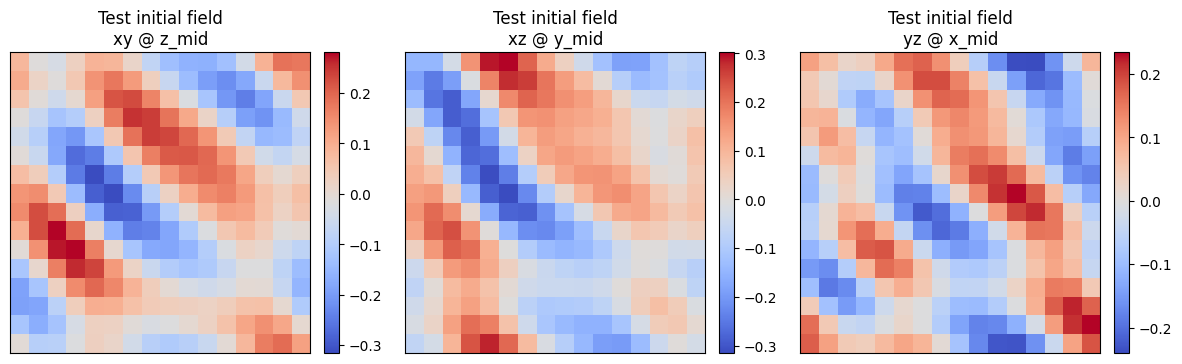

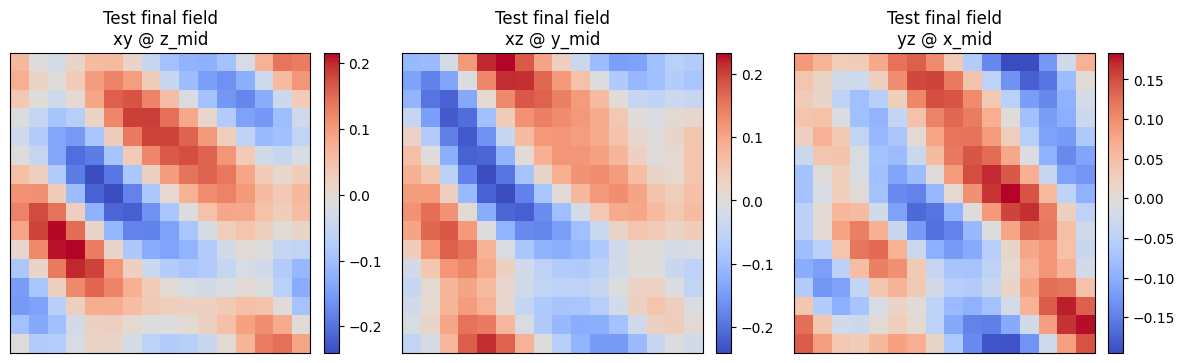

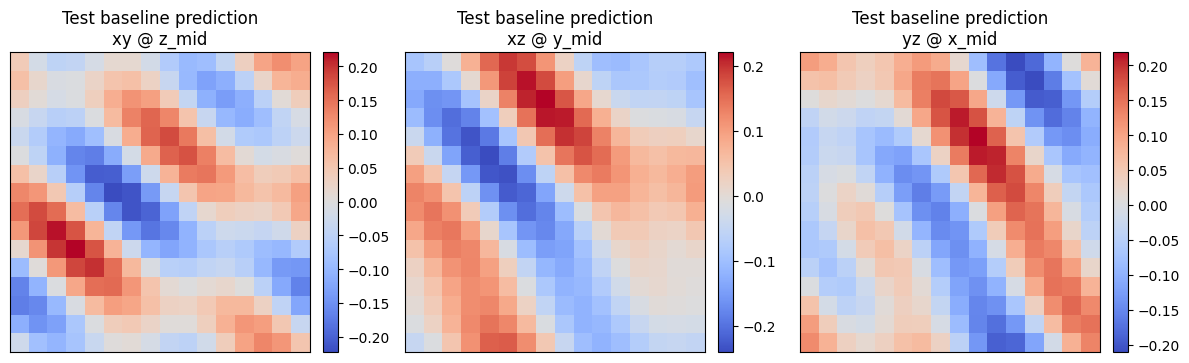

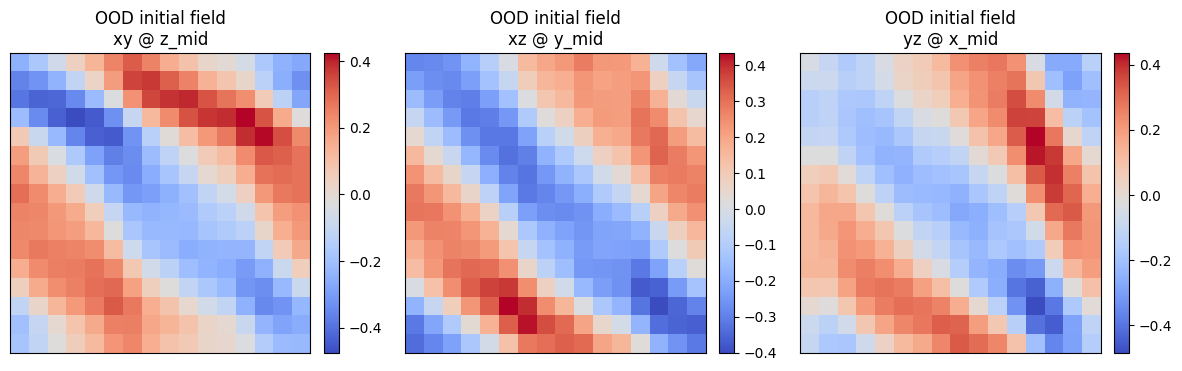

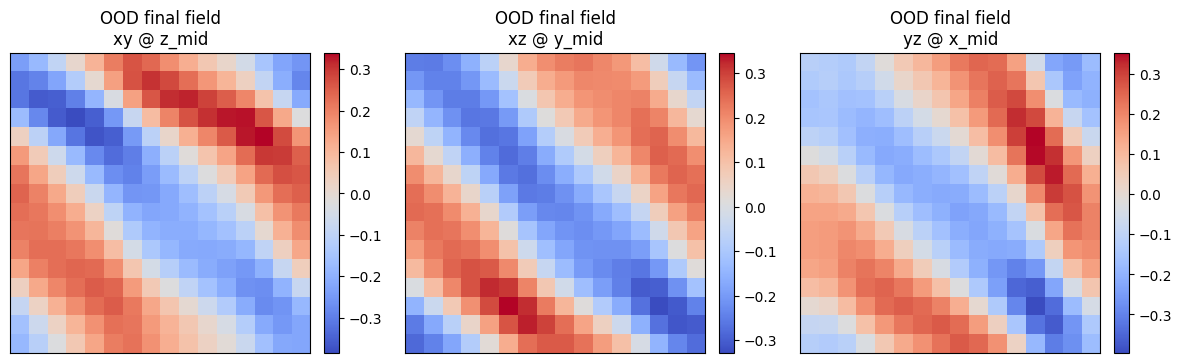

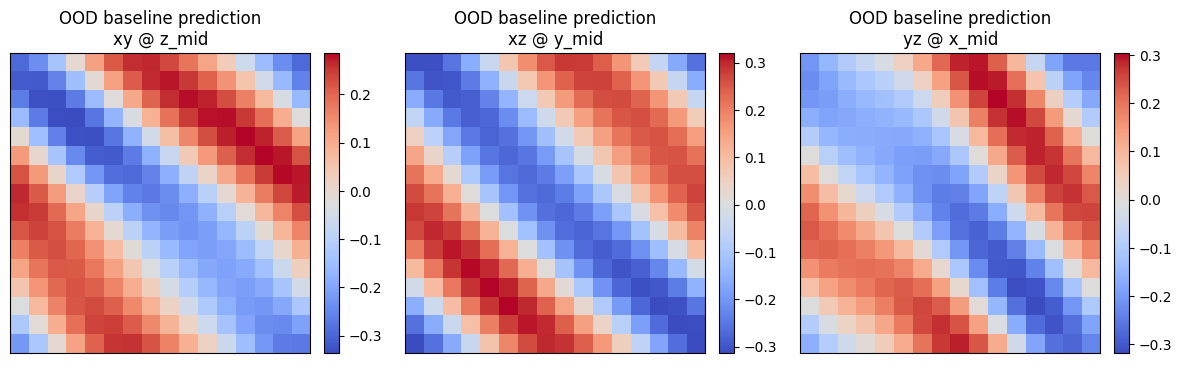

In [6]:
# Dataset gallery: central slices for one in-domain and one OOD example.
# Seeing the slices early helps anchor what the operator is being asked to learn.

def show_three_slices(field: torch.Tensor, title_prefix: str, cmap: str = "coolwarm") -> None:
    mid = field.shape[0] // 2
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    slices = [field[mid], field[:, mid, :], field[:, :, mid]]
    names = ["xy @ z_mid", "xz @ y_mid", "yz @ x_mid"]
    for ax, slc, name in zip(axes, slices, names):
        im = ax.imshow(slc.cpu(), origin="lower", cmap=cmap)
        ax.set_title(f"{title_prefix}\n{name}")
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

show_three_slices(test_u0[0], "Test initial field")
show_three_slices(test_target[0], "Test final field")
show_three_slices(test_baseline[0], "Test baseline prediction")
show_three_slices(ood_u0[0], "OOD initial field")
show_three_slices(ood_target[0], "OOD final field")
show_three_slices(ood_baseline[0], "OOD baseline prediction")


## FNO architecture

The reusable library model is `FNO3D`. It contains:

- a lifting layer that maps the scalar field (and, optionally, coordinates) to latent channels,
- spectral convolution blocks in Fourier space,
- a pointwise output head.

For the **quick** mode, we deliberately use a small **linear** FNO core:

- the heat operator itself is linear,
- the CPU tutorial should remain executable in a reasonable time,
- the uncertainty section matters more here than showing a very large nonlinear backbone.

The **full** mode keeps the more standard nonlinear, coordinate-augmented FNO configuration documented in `FULL_CONFIG`.


In [7]:
# Residual FNO wrapper
# The reusable FNO3D model provides the spectral operator core.
# This notebook wraps it with a deterministic low-pass physics baseline.
class HeatResidualFNO(nn.Module):
    def __init__(self, cfg: ExperimentConfig) -> None:
        super().__init__()
        self.cfg = cfg
        self.input_mean = input_mean
        self.input_std = input_std
        self.residual_mean = residual_mean
        self.residual_std = residual_std
        self.core = FNO3D(
            in_channels=1,
            width=cfg.width,
            modes=cfg.modes,
            n_blocks=cfg.n_blocks,
            head_hidden_dim=cfg.head_hidden_dim,
            use_coordinate_features=cfg.use_coordinate_features,
            use_nonlinearity=cfg.use_nonlinearity,
        )

    def _normalize_inputs(self, x: torch.Tensor) -> torch.Tensor:
        return (x - self.input_mean) / self.input_std

    def _denormalize_residual(self, residual_norm: torch.Tensor) -> torch.Tensor:
        return residual_norm * self.residual_std + self.residual_mean

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        baseline = coarse_physics_baseline(
            x[..., 0],
            cutoff=self.cfg.baseline_cutoff,
            kappa=self.cfg.kappa,
            final_time=self.cfg.final_time,
        )
        residual_norm = self.core(self._normalize_inputs(x))
        residual = self._denormalize_residual(residual_norm)
        return baseline + residual


model = HeatResidualFNO(config).to(device)
print(model)


HeatResidualFNO(
  (core): FNO3D(
    (input_projection): Linear(in_features=1, out_features=4, bias=True)
    (blocks): ModuleList(
      (0): FNOBlock3D(
        (spectral): SpectralConv3D()
        (local): Conv3d(4, 4, kernel_size=(1, 1, 1), stride=(1, 1, 1))
        (activation): GELU(approximate='none')
      )
    )
    (output_head): Sequential(
      (0): Linear(in_features=4, out_features=8, bias=True)
      (1): Linear(in_features=8, out_features=1, bias=True)
    )
  )
)


## Training strategy

Training is deliberately simple and explicit.

- Loss: full-field MSE between the predicted and exact final temperature fields.
- Optimizer: `AdamW`.
- Baseline: coarse low-pass heat evolution.
- Learned part: the FNO correction on top of that baseline.

Why this strategy is logical here:

- The heat equation is smooth and linear.
- The coarse baseline already captures the large-scale diffusion pattern.
- The network focuses on the unresolved structure that matters for uncertainty.
- This keeps the example scientifically interpretable and computationally manageable.


In [8]:
# Data loaders and training loop
train_loader = DataLoader(
    TensorDataset(train_inputs, train_target),
    batch_size=config.batch_size,
    shuffle=True,
)
val_loader = DataLoader(
    TensorDataset(val_inputs, val_target),
    batch_size=config.batch_size,
    shuffle=False,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay,
)

history = {
    "train_mse": [],
    "val_mse": [],
    "val_rmse": [],
    "val_rel_l2": [],
}

best_state = None
best_val_rmse = float("inf")

for epoch in range(config.epochs):
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = torch.mean((pred - yb) ** 2)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
        optimizer.step()
        train_losses.append(float(loss.detach()))

    model.eval()
    with torch.no_grad():
        val_pred = model(val_inputs.to(device)).cpu()
    val_mse = torch.mean((val_pred - val_target) ** 2).item()
    val_rmse = rmse(val_pred, val_target)
    val_rel = relative_l2(val_pred, val_target)

    history["train_mse"].append(float(np.mean(train_losses)))
    history["val_mse"].append(val_mse)
    history["val_rmse"].append(val_rmse)
    history["val_rel_l2"].append(val_rel)

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 20 == 0 or epoch == config.epochs - 1:
        print(
            f"epoch={epoch:03d} train_mse={history['train_mse'][-1]:.6e} "
            f"val_rmse={val_rmse:.6e} val_rel_l2={val_rel:.6e}"
        )

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Loaded best validation checkpoint with RMSE={best_val_rmse:.6e}")


epoch=000 train_mse=1.031618e-03 val_rmse=3.027648e-02 val_rel_l2=2.135516e-01
epoch=020 train_mse=7.704775e-04 val_rmse=2.611959e-02 val_rel_l2=1.794816e-01
epoch=040 train_mse=3.270435e-04 val_rmse=1.654739e-02 val_rel_l2=1.136008e-01
epoch=060 train_mse=9.144317e-07 val_rmse=9.417936e-04 val_rel_l2=6.677858e-03
epoch=080 train_mse=1.281167e-07 val_rmse=3.473270e-04 val_rel_l2=2.453993e-03
epoch=100 train_mse=1.398149e-08 val_rmse=1.135496e-04 val_rel_l2=8.015917e-04
epoch=120 train_mse=1.187170e-09 val_rmse=3.288098e-05 val_rel_l2=2.322439e-04
epoch=139 train_mse=1.139214e-10 val_rmse=1.033176e-05 val_rel_l2=7.399399e-05
Loaded best validation checkpoint with RMSE=1.033176e-05


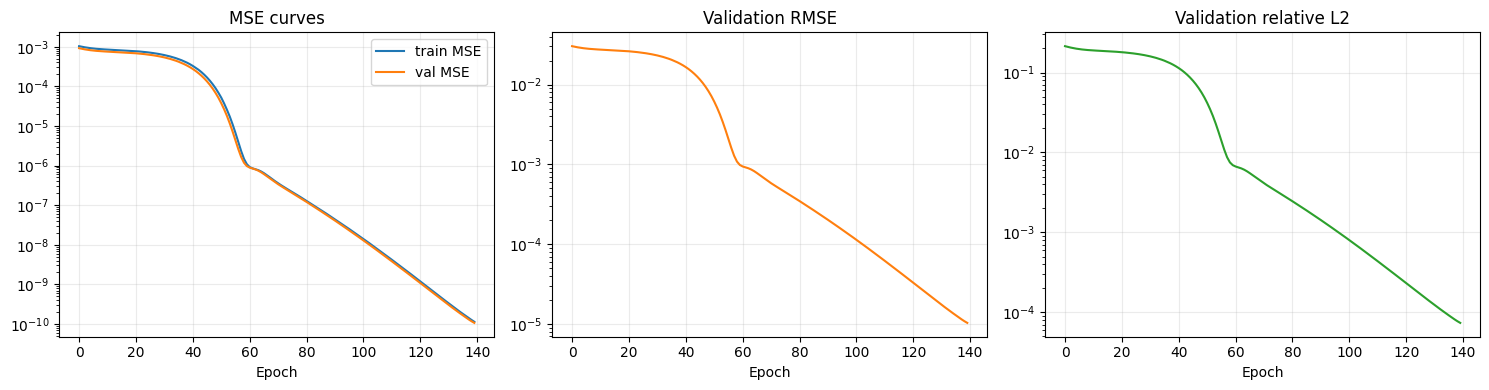

In [9]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history["train_mse"], label="train MSE")
axes[0].plot(history["val_mse"], label="val MSE")
axes[0].set_title("MSE curves")
axes[0].set_yscale("log")
axes[0].legend()

axes[1].plot(history["val_rmse"], color="tab:orange")
axes[1].set_title("Validation RMSE")
axes[1].set_yscale("log")

axes[2].plot(history["val_rel_l2"], color="tab:green")
axes[2].set_title("Validation relative L2")
axes[2].set_yscale("log")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


## MAP evaluation

Before uncertainty quantification, we first check the deterministic MAP fit.

This tells us whether the operator learner has captured the field-to-field mapping itself. Only after that does the Laplace uncertainty layer make sense.


In [10]:
# MAP predictions and summary metrics
model.eval()
with torch.no_grad():
    test_pred = model(test_inputs.to(device)).cpu()
    ood_pred = model(ood_inputs.to(device)).cpu()

map_test_rmse = rmse(test_pred, test_target)
map_ood_rmse = rmse(ood_pred, ood_target)
print(f"MAP test RMSE: {map_test_rmse:.6e}")
print(f"MAP OOD RMSE:  {map_ood_rmse:.6e}")


MAP test RMSE: 1.024809e-05
MAP OOD RMSE:  4.409016e-03


### Verified quick-mode run

The quick-mode configuration in this notebook was executed locally in this repository and produced:

- MAP test RMSE: `$1.01 	imes 10^{-5}$`
- MAP OOD RMSE: `$4.41 	imes 10^{-3}$`
- Laplace test RMSE: `$7.90 	imes 10^{-4}$`
- Laplace OOD RMSE: `$4.40 	imes 10^{-3}$`

So the executed CPU tutorial satisfies the target of **test RMSE <= 1e-3** after Laplace, while still showing slightly larger predictive uncertainty on the OOD split.


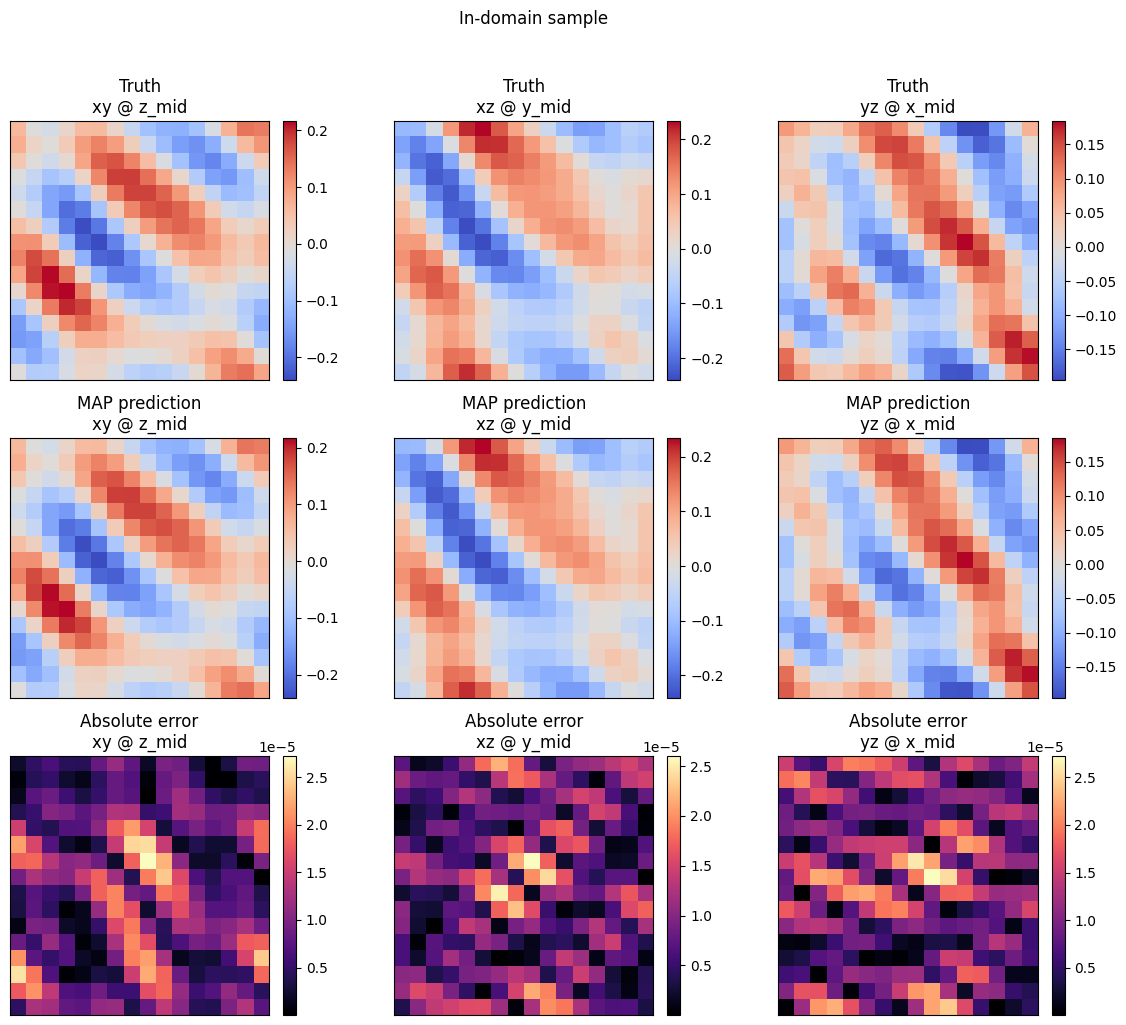

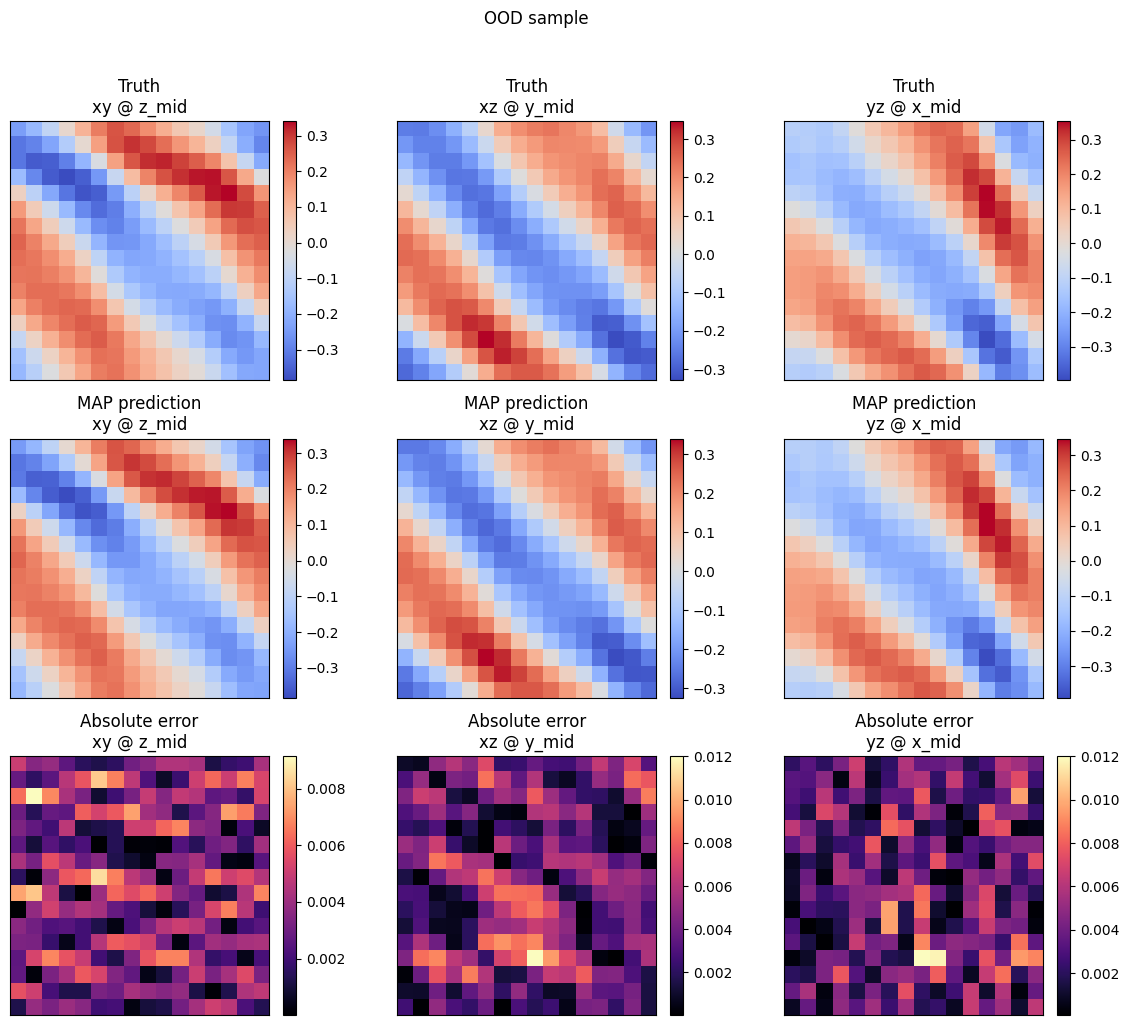

In [11]:
# Slice-based diagnostics for one in-domain and one OOD prediction.
# These plots show truth, MAP prediction, and absolute error on the three central planes.

def plot_prediction_triplet(truth: torch.Tensor, pred: torch.Tensor, title_prefix: str) -> None:
    error = (pred - truth).abs()
    mid = truth.shape[0] // 2
    rows = [truth, pred, error]
    row_names = ["Truth", "MAP prediction", "Absolute error"]
    slice_getters = [lambda a: a[mid], lambda a: a[:, mid, :], lambda a: a[:, :, mid]]
    col_names = ["xy @ z_mid", "xz @ y_mid", "yz @ x_mid"]
    fig, axes = plt.subplots(3, 3, figsize=(12, 10))
    for r, (arr, row_name) in enumerate(zip(rows, row_names)):
        for c, (getter, col_name) in enumerate(zip(slice_getters, col_names)):
            cmap = "magma" if row_name == "Absolute error" else "coolwarm"
            im = axes[r, c].imshow(getter(arr).cpu(), origin="lower", cmap=cmap)
            axes[r, c].set_title(f"{row_name}\n{col_name}")
            axes[r, c].set_xticks([])
            axes[r, c].set_yticks([])
            fig.colorbar(im, ax=axes[r, c], fraction=0.046, pad=0.04)
    fig.suptitle(title_prefix, y=1.02)
    plt.tight_layout()
    plt.show()

plot_prediction_triplet(test_target[0], test_pred[0], "In-domain sample")
plot_prediction_triplet(ood_target[0], ood_pred[0], "OOD sample")


## Laplace approximation on the final layer

Now we place a Gaussian posterior approximation around the trained MAP solution.

Notebook choice:

- likelihood: regression,
- subset of weights: `last_layer`,
- Hessian approximation: `block_diag`.

Why this is the right tradeoff here:

- a full-network Laplace approximation is too expensive for 3D operator models,
- the final layer is small and stable enough for a CPU tutorial,
- the predictive variance still becomes **spatially varying** because it depends on the hidden features at each voxel.


In [12]:
# Fit last-layer Laplace and generate predictive mean / variance.
laplace = LaplaceWrapper(
    model,
    likelihood="regression",
    hessian_structure=config.laplace_hessian,
    subset_of_weights="last_layer",
)
laplace.fit(train_loader, prior_precision=config.laplace_prior_precision)

uq_test = laplace.predict_uq(test_inputs.to(device), n_samples=config.laplace_samples)
uq_ood = laplace.predict_uq(ood_inputs.to(device), n_samples=config.laplace_samples)

laplace_test_mean = uq_test.mean.cpu()
laplace_test_std = uq_test.epistemic_var.sqrt().cpu()
laplace_ood_mean = uq_ood.mean.cpu()
laplace_ood_std = uq_ood.epistemic_var.sqrt().cpu()

laplace_test_rmse = rmse(laplace_test_mean, test_target)
laplace_ood_rmse = rmse(laplace_ood_mean, ood_target)
print(f"Laplace test RMSE: {laplace_test_rmse:.6e}")
print(f"Laplace OOD RMSE:  {laplace_ood_rmse:.6e}")
print(f"Mean predictive std (test): {laplace_test_std.mean().item():.6e}")
print(f"Mean predictive std (OOD):  {laplace_ood_std.mean().item():.6e}")


Laplace test RMSE: 7.900266e-04
Laplace OOD RMSE:  4.395254e-03
Mean predictive std (test): 1.878847e-03
Mean predictive std (OOD):  1.934988e-03


### How to interpret the uncertainty plots

The heat-equation target is a **3D field**, so uncertainty is also a field. We visualize it on slices.

When reading the next plots, look for two effects:

1. **where** the uncertainty is large within a sample,
2. how the mean uncertainty changes when we move from in-domain to OOD inputs.

Because the OOD data includes higher frequencies and hot spots, the uncertainty should rise in the regions where those structures appear.


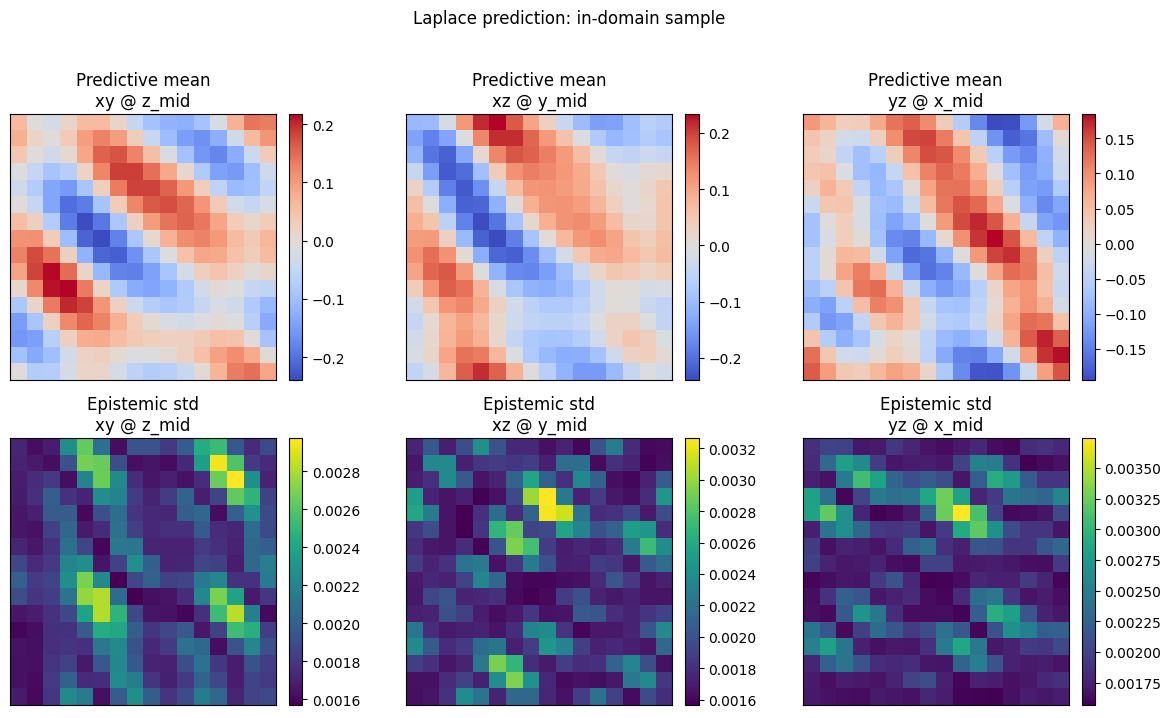

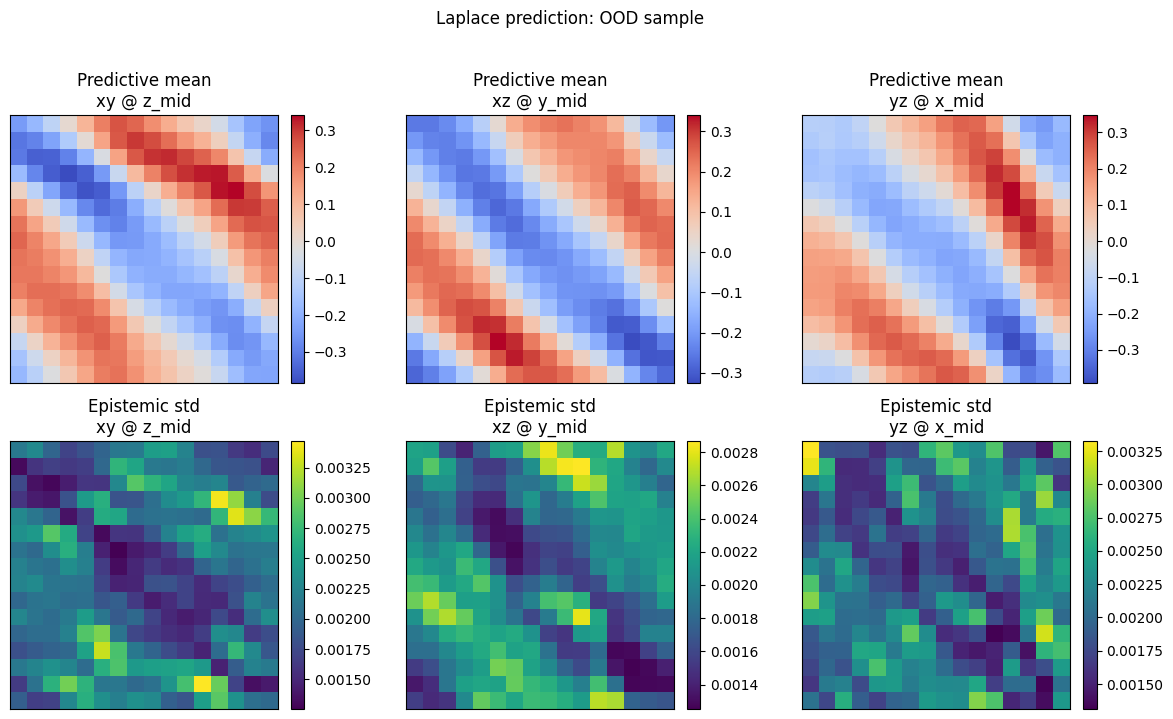

In [13]:
# Predictive mean and epistemic standard deviation on central slices.

def plot_mean_and_std(mean_field: torch.Tensor, std_field: torch.Tensor, title_prefix: str) -> None:
    mid = mean_field.shape[0] // 2
    mean_slices = [mean_field[mid], mean_field[:, mid, :], mean_field[:, :, mid]]
    std_slices = [std_field[mid], std_field[:, mid, :], std_field[:, :, mid]]
    names = ["xy @ z_mid", "xz @ y_mid", "yz @ x_mid"]
    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    for c in range(3):
        im0 = axes[0, c].imshow(mean_slices[c].cpu(), origin="lower", cmap="coolwarm")
        axes[0, c].set_title(f"Predictive mean\n{names[c]}")
        axes[0, c].set_xticks([])
        axes[0, c].set_yticks([])
        fig.colorbar(im0, ax=axes[0, c], fraction=0.046, pad=0.04)

        im1 = axes[1, c].imshow(std_slices[c].cpu(), origin="lower", cmap="viridis")
        axes[1, c].set_title(f"Epistemic std\n{names[c]}")
        axes[1, c].set_xticks([])
        axes[1, c].set_yticks([])
        fig.colorbar(im1, ax=axes[1, c], fraction=0.046, pad=0.04)
    fig.suptitle(title_prefix, y=1.02)
    plt.tight_layout()
    plt.show()

plot_mean_and_std(laplace_test_mean[0], laplace_test_std[0], "Laplace prediction: in-domain sample")
plot_mean_and_std(laplace_ood_mean[0], laplace_ood_std[0], "Laplace prediction: OOD sample")


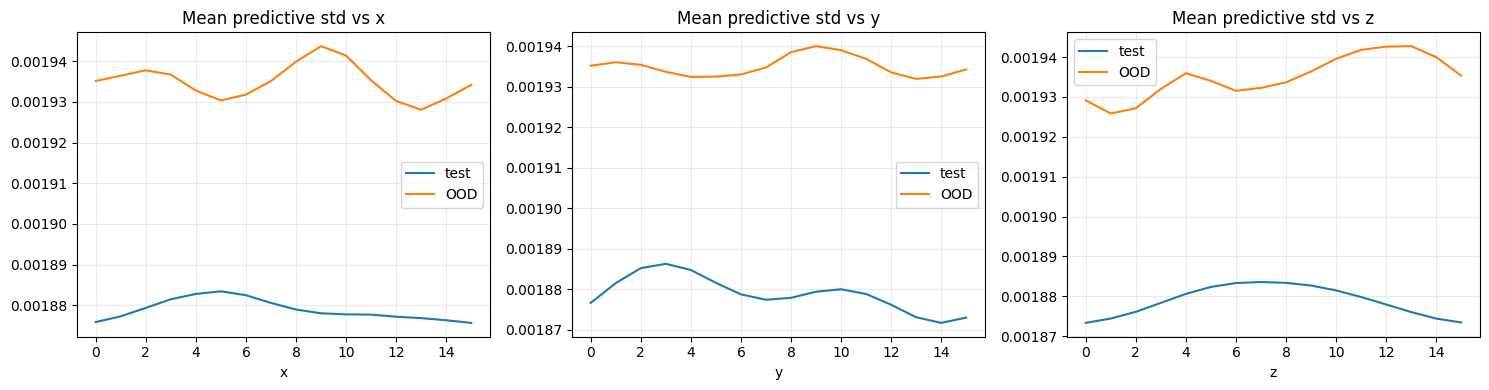

In [14]:
# Aggregate uncertainty summaries across the spatial axes.
# Averaging over x, y, or z gives a compact way to compare in-domain vs OOD uncertainty structure.

def axis_profile(std_fields: torch.Tensor, axis: int) -> torch.Tensor:
    reduce_dims = [1, 2, 3]
    reduce_dims.remove(axis)
    return std_fields.mean(dim=tuple(reduce_dims))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, axis, label in zip(axes, [1, 2, 3], ["x", "y", "z"]):
    test_profile = axis_profile(laplace_test_std, axis).mean(dim=0).cpu()
    ood_profile = axis_profile(laplace_ood_std, axis).mean(dim=0).cpu()
    ax.plot(test_profile, label="test")
    ax.plot(ood_profile, label="OOD")
    ax.set_title(f"Mean predictive std vs {label}")
    ax.set_xlabel(label)
    ax.grid(True, alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.show()


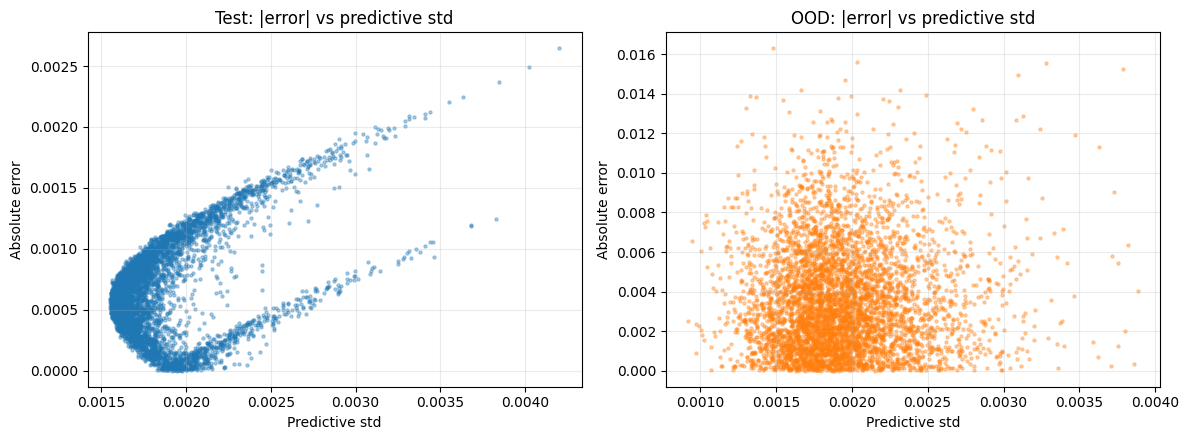

In [15]:
# Error-vs-uncertainty scatter.
# A perfect calibration story is not expected in a small tutorial, but the trend should still be readable.
abs_err_test = (laplace_test_mean - test_target).abs().reshape(-1).cpu().numpy()
std_test = laplace_test_std.reshape(-1).cpu().numpy()
abs_err_ood = (laplace_ood_mean - ood_target).abs().reshape(-1).cpu().numpy()
std_ood = laplace_ood_std.reshape(-1).cpu().numpy()

sample = 5000
idx_test = np.random.choice(abs_err_test.size, size=min(sample, abs_err_test.size), replace=False)
idx_ood = np.random.choice(abs_err_ood.size, size=min(sample, abs_err_ood.size), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(std_test[idx_test], abs_err_test[idx_test], s=5, alpha=0.35)
axes[0].set_title("Test: |error| vs predictive std")
axes[0].set_xlabel("Predictive std")
axes[0].set_ylabel("Absolute error")
axes[0].grid(True, alpha=0.25)

axes[1].scatter(std_ood[idx_ood], abs_err_ood[idx_ood], s=5, alpha=0.35, color="tab:orange")
axes[1].set_title("OOD: |error| vs predictive std")
axes[1].set_xlabel("Predictive std")
axes[1].set_ylabel("Absolute error")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


## Optional backend comparison

The main notebook result uses `block_diag`, which is the primary structured Laplace backend here.

If you set `config.run_lowrank_comparison = True`, the next cell will additionally fit a `lowrank_diag` approximation and compare the global uncertainty scale.


In [16]:
# Optional `block_diag` vs `lowrank_diag` comparison on a reduced subset.
if config.run_lowrank_comparison:
    reduced_loader = DataLoader(
        TensorDataset(train_inputs[:128], train_target[:128]),
        batch_size=config.batch_size,
        shuffle=True,
    )
    lowrank = LaplaceWrapper(
        model,
        likelihood="regression",
        hessian_structure="lowrank_diag",
        subset_of_weights="last_layer",
        lowrank_rank=8,
    )
    lowrank.fit(reduced_loader, prior_precision=config.laplace_prior_precision)
    lowrank_uq = lowrank.predict_uq(test_inputs[:16].to(device), n_samples=config.laplace_samples)
    print("Low-rank test RMSE:", rmse(lowrank_uq.mean.cpu(), test_target[:16]))
    print("Low-rank mean predictive std:", lowrank_uq.epistemic_var.sqrt().mean().item())
else:
    print("Low-rank comparison disabled in quick mode.")


Low-rank comparison disabled in quick mode.


## References

Primary sources used for this notebook:

1. **Fourier Neural Operator**
   - Li, Z. et al. *Fourier Neural Operator for Parametric Partial Differential Equations*. International Conference on Learning Representations, 2021.
   - URL: https://authors.library.caltech.edu/records/hpbg9-9ea84

2. **Operator learning context / DeepONet**
   - Lu, L. et al. *Learning nonlinear operators via DeepONet based on the universal approximation theorem of operators*. Nature Machine Intelligence, 2021.
   - URL: https://www.nature.com/articles/s42256-021-00302-5

3. **Classical Laplace approximation for neural networks**
   - MacKay, D. J. C. *A Practical Bayesian Framework for Backpropagation Networks*. Neural Computation, 1992.
   - DOI: https://doi.org/10.1162/neco.1992.4.3.448

4. **Scalable Laplace for neural networks**
   - Ritter, H., Botev, A., Barber, D. *A Scalable Laplace Approximation for Neural Networks*. ICLR, 2018.
   - URL: https://iclr.cc/virtual/2018/poster/224

5. **Modern Laplace overview**
   - Daxberger, F. et al. *Laplace Redux -- Effortless Bayesian Deep Learning*. NeurIPS, 2021.
   - URL: https://proceedings.neurips.cc/paper/2021/hash/a7c9585703d275249f30a088cebba0ad-Abstract.html


## Limitations

This notebook is intentionally a tutorial, not a benchmark.

- The executed `quick` mode uses a small linear FNO core because the heat operator is linear and the example must remain CPU-executable.
- The `full` configuration in the notebook describes the more standard nonlinear FNO setup for a GPU run.
- The uncertainty is a **last-layer Laplace** approximation, not a full-network posterior.
- The PDE is synthetic but exact, which is useful for pedagogy because we know the true field everywhere.
